# 在ChemLLMBench上对ChemBart进行测试
- 由于ChemBart和语言模型的本质差别，仅借鉴了数据集，评估方法仍遵从8：1：1的训练集:验证集:测试集划分
- ChemBart的训练模式和语言模型相同，但由于训练语料完全脱离自然语言，不具有大预言模型能力，而是纯粹的化学SMILES语言模型

## SM产率预测-清晰低产率数据

In [ ]:
import sys
import os

ROOT_DIR = "/path/to/your/project"  # change this to your actual project path
chembart_path = os.path.join(ROOT_DIR, "model")

if chembart_path not in sys.path:
    sys.path.insert(0, chembart_path)
    
from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np


[2025-08-12 15:23:32,855] [INFO] [real_accelerator.py:203:get_accelerator] Setting ds_accelerator to cuda (auto detect)
 [WARNING]  Please specify the CUTLASS repo directory as environment variable $CUTLASS_PATH
 [WARNING]  please install triton==1.0.0 if you want to use sparse attention


In [2]:

def make_plot(y_test, y_pred, name):
    # 设置统一字体大小
    fontsize = 28
    label_fontsize = 32
    tick_fontsize = 26
    
    # 调整图形大小为正方形 (9x9)，与前两个图一致
    fig, ax = plt.subplots(figsize=(10, 9))
    
    # 计算指标
    rmse = mean_squared_error(y_test, y_pred, squared=False)
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    
    # 指标文本格式（保持3位小数）
    metrics_text = f"R² = {r2:.3f}\nRMSE = {rmse:.1f}\nMAE = {mae:.1f}"
    
    # 设置坐标轴范围
    plt.xlim(-5, 105)
    plt.ylim(-5, 105)
    
    # 绘制散点图（使用与热力图协调的蓝色系）
    plt.scatter(y_pred, y_test, alpha=0.4, color="#1f77b4", s=60)  # 调整点的大小和透明度
    
    # 绘制对角线（样式与热力图协调）
    plt.plot(np.arange(100), np.arange(100), ls="--", c=".3", linewidth=2)
    
    # 添加指标文本（右上角）
    ax.text(0.05, 0.95, metrics_text, 
            transform=ax.transAxes,
            ha='left', va='top',
            fontsize=fontsize,
            bbox=dict(facecolor='white', alpha=0.8, boxstyle='round,pad=0.5'))
    
    # 设置坐标轴标签（加大字体）
    ax.set_ylabel('True', fontsize=label_fontsize)
    ax.set_xlabel('Predicted', fontsize=label_fontsize)
    ax.set_title(name, fontsize=label_fontsize)  # 增加标题间距
    
    # 设置刻度标签大小
    plt.tick_params(axis='both', which='major', labelsize=tick_fontsize)
    
    # 调整布局（确保标签不超出画布）
    plt.tight_layout()
    
    plt.show()

In [14]:
import json
import os

# 输入和输出路径设置
input_base_dir = 'data/yield/Suzuki-Miyaura_splits'
output_base_dir = 'data/yield/SM_cleaned'

# 创建输出目录（如果不存在）
os.makedirs(output_base_dir, exist_ok=True)

# 遍历 sm0.json 到 sm9.json
for i in range(10):
    json_file_path = f'{input_base_dir}/sm{i}.json'
    cleaned_file_path = f'{output_base_dir}/sm{i}.json'

    # 检查输入文件是否存在
    if not os.path.exists(json_file_path):
        print(f"警告: 文件不存在 - {json_file_path}")
        continue

    # 读取 JSON 文件
    with open(json_file_path, 'r') as f:
        data = json.load(f)

    # 存储所有产率和清洗后的数据
    yields = []
    cleaned_data = []

    # 遍历数据，提取产率并清洗
    for item in data:
        try:
            reaction, yield_list = item
            yield_value = yield_list[0]  # 假设产率是单元素列表

            # 确保产率是数值且大于0
            if isinstance(yield_value, (int, float)) and yield_value > 0.01:
                yields.append(yield_value)
                cleaned_data.append(item)
        except (IndexError, ValueError, TypeError) as e:
            print(f"警告: 数据格式错误，跳过条目 - {item}, 错误: {e}")
            continue

    # 统计信息
    print(f"\n--- sm{i}.json ---")
    print(f"原始数据条数: {len(data)}")
    print(f"清洗后（产率>0）数据条数: {len(cleaned_data)}")
    if yields:
        print(f"产率统计信息:")
        print(f"  最小值: {min(yields):.2f}")
        print(f"  最大值: {max(yields):.2f}")
        print(f"  平均值: {sum(yields)/len(yields):.2f}")
        print(f"  中位数: {sorted(yields)[len(yields)//2]:.2f}")
    else:
        print("清洗后无有效产率数据")

    # 保存清洗后的数据
    with open(cleaned_file_path, 'w') as f:
        json.dump(cleaned_data, f, indent=2)

    print(f"清洗后的数据已保存至: {cleaned_file_path}")

print("\n✅ 所有文件处理完成！")



--- sm0.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数: 0.36
清洗后的数据已保存至: data/yield/SM_cleaned/sm0.json

--- sm1.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数: 0.36
清洗后的数据已保存至: data/yield/SM_cleaned/sm1.json

--- sm2.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数: 0.36
清洗后的数据已保存至: data/yield/SM_cleaned/sm2.json

--- sm3.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数: 0.36
清洗后的数据已保存至: data/yield/SM_cleaned/sm3.json

--- sm4.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数: 0.36
清洗后的数据已保存至: data/yield/SM_cleaned/sm4.json

--- sm5.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数: 0.36
清洗后的数据已保存至: data/yield/SM_cleaned/sm5.json

--- sm6.json ---
原始数据条数: 5760
清洗后（产率>0）数据条数: 5469
产率统计信息:
  最小值: 0.01
  最大值: 1.00
  平均值: 0.42
  中位数

In [8]:
json_file_path = 'data/yield/SM_cleaned/sm0.json'
with open(json_file_path, 'r') as f:
    data = json.load(f)

max([len(item[0]) for item in data])

268

In [ ]:
#训练：验证：测试 6：1：3
from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

TRAIN = True
LABEL_NUM = 1

task_token = ["<n00>", "<n01>", "<n02>","<n03>", "<n04>"]
ends = "".join(task_token[:LABEL_NUM - 1]) + "<end>"

for i in range(0, 10):
    json_file_path = f'data/yield/SM_cleaned/sm{i}.json'
    model_name = f"Suzuki-Miyaura_cleaned{i}"
    c = CB_Regression(name = model_name, pre_model='ChemBart_MIT_6',label_num = LABEL_NUM, device = "cuda:2") #"cuda:0", "cuda:1" etc.
    with open(json_file_path) as f:
        l = json.load(f)
    for i in range(len(l)):
        l[i][0] += ends
    print(l[1])

    #划分数据集
    train_prop = 0.6
    valid_prop = 0.1

    train_size = int(train_prop*len(l))
    valid_size = int(valid_prop*len(l))
    test_size = len(l) - train_size - valid_size

    #数据标准化
    # 提取标签值
    labels = [item[1] for item in l]
    # 计算训练集的均值和标准差
    train_labels = labels[:train_size]
    mean = np.mean(train_labels)
    std = np.std(train_labels)
    # 标准化标签值
    standardized_labels = [(label - mean) / std for label in labels]
    # 将标准化后的标签值放回原始数据中
    for i, item in enumerate(l):
        l[i][1] = [float(standardized_labels[i])]
    print(l[1])

    if TRAIN:
        c.fit(data = l[0:train_size+valid_size], epoch = 1000, batch_size = 4, tr=train_size, val=valid_size, te = test_size, id_maxlen =300 )
        #data, epoch, batch size, train num, val num, test num, max input length
    else:
        out = c.test(l[-test_size:-1], batch_size = 4)
        print(out)
    
    (RMSE_list, reslist) = c.test(l[-test_size:-1], batch_size = 4)

    # 提取预测值和标签
    y_pred, y_test = [], []
    for sublist in reslist:
        # 确保每个子列表中的元素都是二元组 (prediction, label)
        if all(isinstance(item, tuple) and len(item) == 2 for item in sublist):
            y_pred.extend([(item[0] * std + mean)*100 for item in sublist])
            y_pred = np.clip(y_pred, 0, 100)
            y_test.extend([(item[1] * std + mean)*100 for item in sublist])
        else:
            raise ValueError("Each element in sublist must be a tuple of length 2.")
    plot = make_plot(y_test, y_pred, model_name)

fine-tuned model Suzuki-Miyaura_cleaned0.pth
['C1CCOC1.CC(=O)OCC(=O)O[Pd].CCc1cccc(CC)c1.CN(C)c1ccc(P(C(C)(C)C)C(C)(C)C)cc1.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.Clc1ccc2ncccc2c1.O.[Na+].[OH-]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.612000810462792]]
['C1CCOC1.CC(=O)OCC(=O)O[Pd].CCc1cccc(CC)c1.CN(C)c1ccc(P(C(C)(C)C)C(C)(C)C)cc1.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.Clc1ccc2ncccc2c1.O.[Na+].[OH-]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.6840945465658944]]
([0.442134012269941], [[(0.6753864288330078, -0.043093740940093994), (1.0724109411239624, 1.150712013244629), (-1.3494185209274292, -1.3862037658691406), (-0.15408870577812195, 0.02072085626423359), (-1.12240469455719, -0.9509197473526001), (-1.3707331418991089, -1.3251619338989258), (1.8281680345535278, 1.8803499937057495), (-0.4496467411518097, -0.9942981600761414), (-0.9178531169891357, -0.2808707058429718), (-0.7976899147033691, -0.33178427815437317), (-0.331987589597702, -0.17366914451122284), (1.4152830839157104, 1.737607955

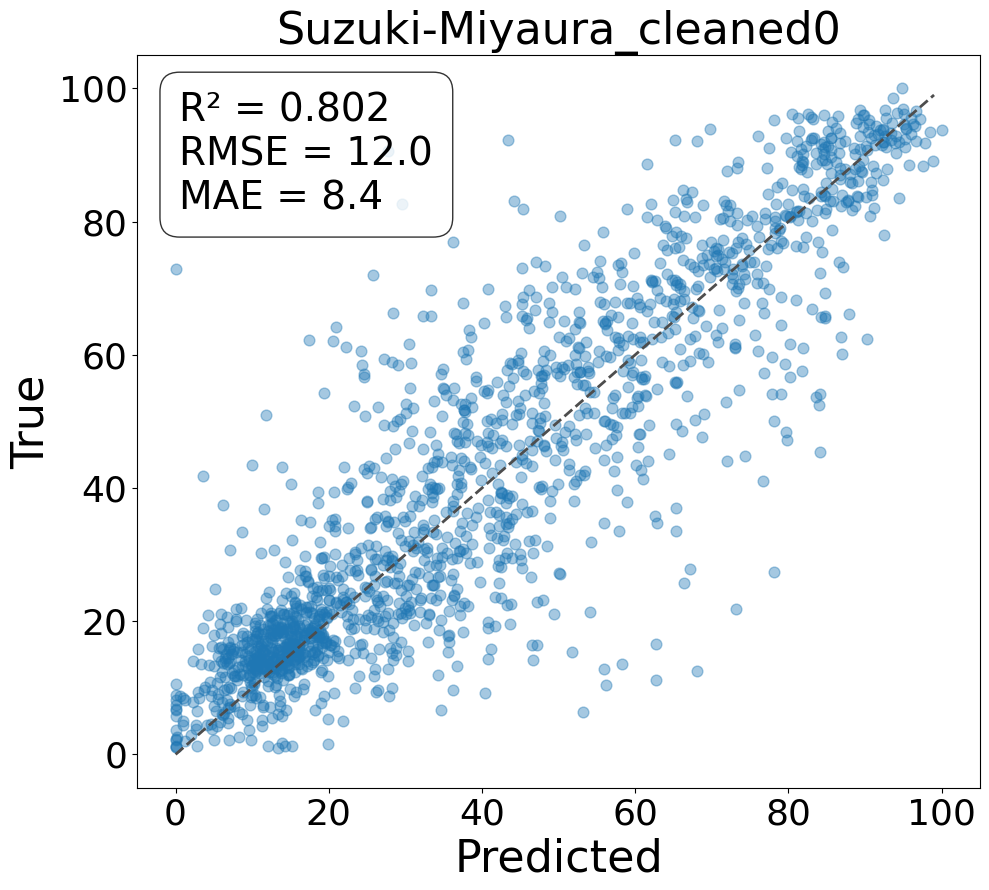

fine-tuned model Suzuki-Miyaura_cleaned1.pth
['CC#N.CC(=O)OCC(=O)O[Pd].CC(C)(C)[O-].CC1(C)OB(c2ccc3ncccc3c2)OC1(C)C.Cc1ccc2c(cnn2C2CCCCO2)c1Br.O.O.[Li+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.51334598789855]]
['CC#N.CC(=O)OCC(=O)O[Pd].CC(C)(C)[O-].CC1(C)OB(c2ccc3ncccc3c2)OC1(C)C.Cc1ccc2c(cnn2C2CCCCO2)c1Br.O.O.[Li+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.34482893677982424]]
([0.43095158032180647], [[(0.4841555058956146, 0.7070022821426392), (-0.11735068261623383, -0.7396718263626099), (-0.9886230230331421, -0.8739878535270691), (0.7440683841705322, 1.8552749156951904), (-1.0426799058914185, -0.9381247162818909), (-0.6749582290649414, -0.7520400881767273), (1.4265531301498413, 1.2729153633117676), (-0.8913357257843018, -0.941619336605072), (0.19596578180789948, 0.29139190912246704), (1.2149773836135864, 0.7157191634178162), (-1.1114331483840942, -0.9668342471122742), (-1.174456238746643, -0.808011531829834), (-0.45829278230667114, -0.6778546571731567), (-1.0538926

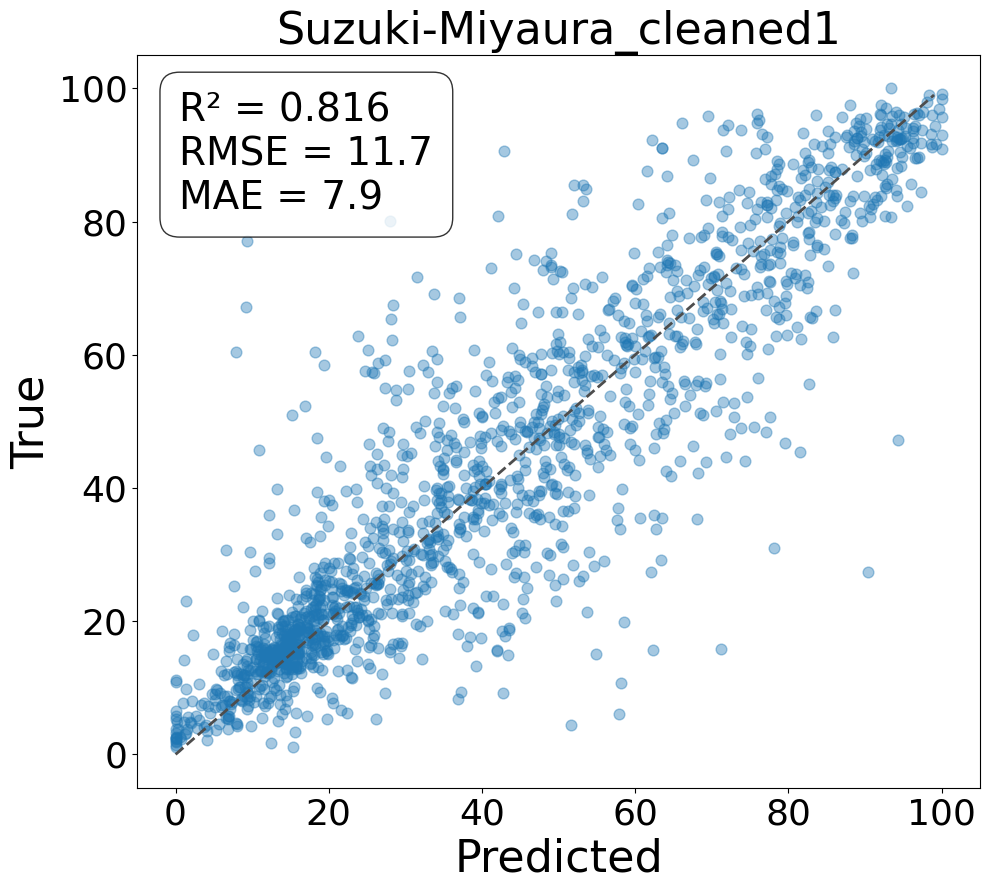

fine-tuned model Suzuki-Miyaura_cleaned2.pth
['Brc1ccc2ncccc2c1.CC#N.CC(=O)OCC(=O)O[Pd].CCc1cccc(CC)c1.CN(C)c1ccc(P(C(C)(C)C)C(C)(C)C)cc1.Cc1ccc2c(cnn2C2CCCCO2)c1[B-](F)(F)F.O.O=P([O-])([O-])[O-].[K+].[K+].[K+].[K+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.178764241294788]]
['Brc1ccc2ncccc2c1.CC#N.CC(=O)OCC(=O)O[Pd].CCc1cccc(CC)c1.CN(C)c1ccc(P(C(C)(C)C)C(C)(C)C)cc1.Cc1ccc2c(cnn2C2CCCCO2)c1[B-](F)(F)F.O.O=P([O-])([O-])[O-].[K+].[K+].[K+].[K+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [-0.9122797817776656]]
([0.42347190704324084], [[(1.1019680500030518, 0.4778830409049988), (0.35862284898757935, -0.8358070850372314), (-0.6345558166503906, -0.7345390319824219), (0.307377427816391, -0.4570470154285431), (-0.2325735241174698, -0.495342493057251), (1.4502290487289429, 1.3082352876663208), (0.24758358299732208, 0.4217112958431244), (1.829781174659729, 1.709234595298767), (-0.9957468509674072, -0.9957563877105713), (2.188194751739502, 1.841843605041504), (1.7041822671890259, 1.

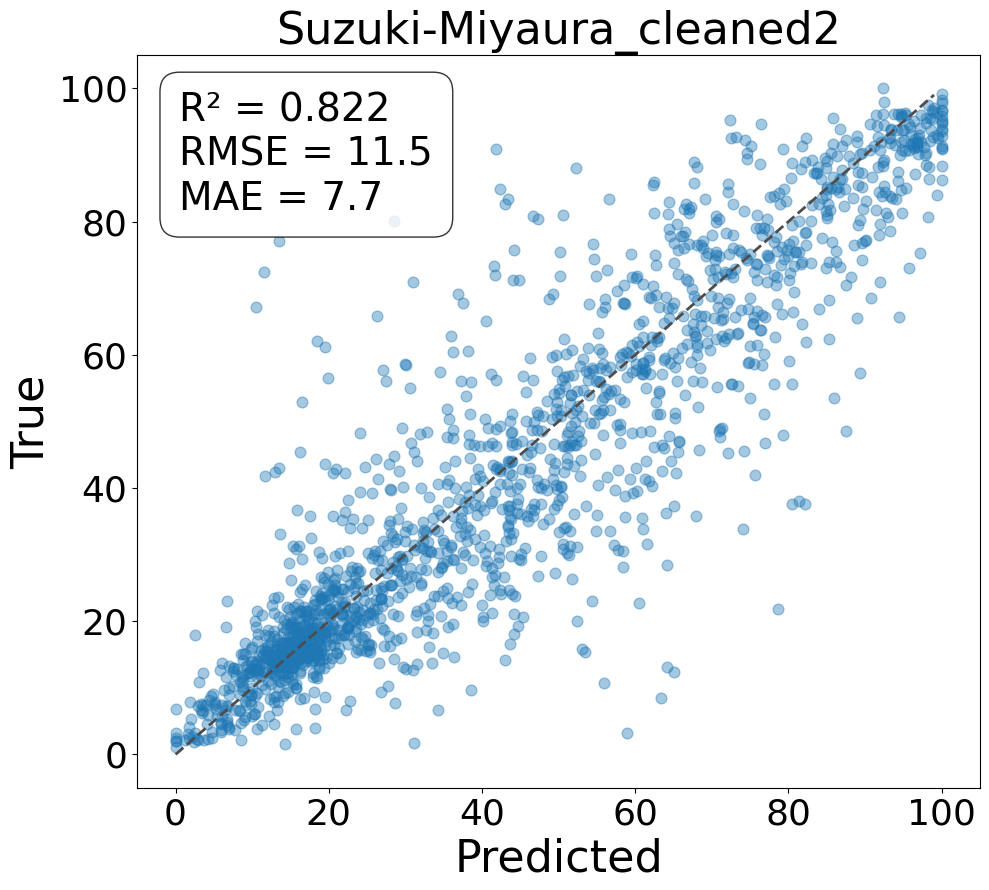

fine-tuned model Suzuki-Miyaura_cleaned3.pth
['C1CCOC1.CC(=O)OCC(=O)O[Pd].CCN(CC)CC.CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.Cc1ccccc1P(c1ccccc1C)c1ccccc1C.O.O=S(=O)(Oc1ccc2ncccc2c1)C(F)(F)F>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.540637459059965]]
['C1CCOC1.CC(=O)OCC(=O)O[Pd].CCN(CC)CC.CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.Cc1ccccc1P(c1ccccc1C)c1ccccc1C.O.O=S(=O)(Oc1ccc2ncccc2c1)C(F)(F)F>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.42733717887059225]]
([0.4812513207613882], [[(1.4577136039733887, 0.9706007242202759), (-1.290736436843872, -1.1160231828689575), (1.2267181873321533, 1.0408138036727905), (-0.8602011203765869, -0.7565276026725769), (-1.1796029806137085, -0.9681552648544312), (-0.2387247532606125, -0.8335348963737488), (0.7918762564659119, 0.2752033770084381), (0.20607398450374603, 0.7103009223937988), (0.6097329258918762, 1.4322456121444702), (-1.204681158065796, -0.9837311506271362), (-0.9162183403968811, -0.9596989750862122), (0.60748887062072

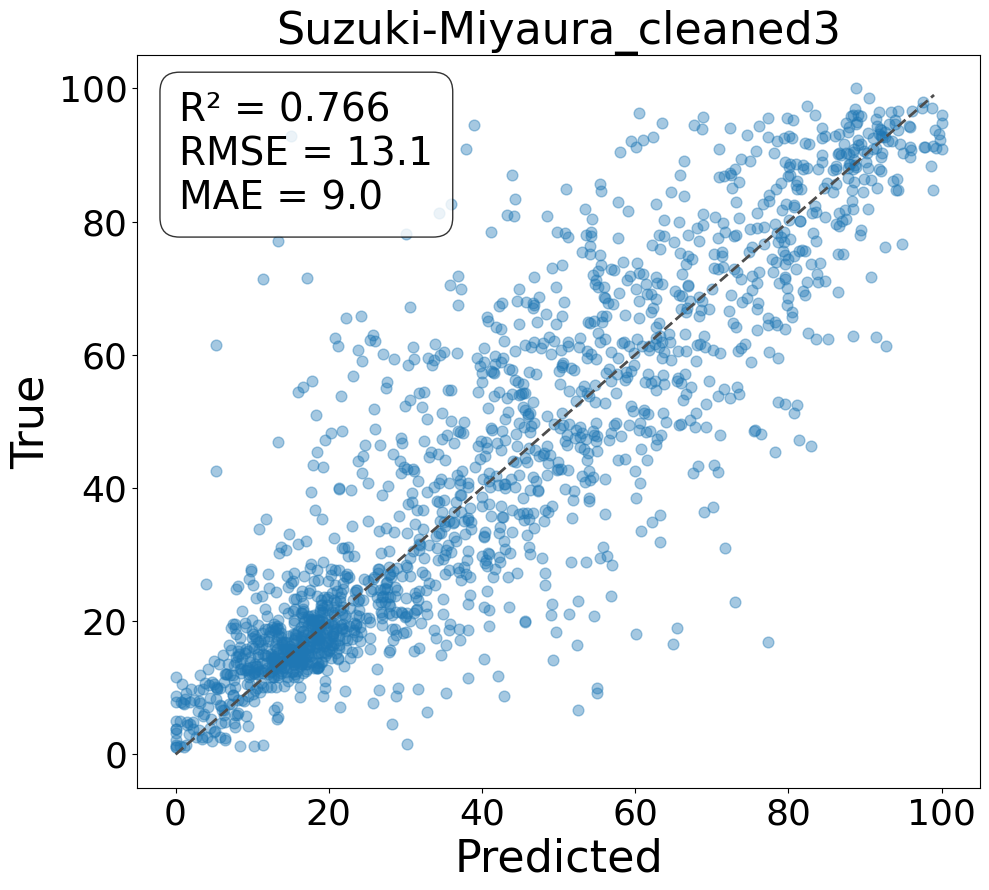

fine-tuned model Suzuki-Miyaura_cleaned4.pth
['CC#N.CC(=O)OCC(=O)O[Pd].CC(C)(C)[O-].CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B1OC(C)(C)C(C)(C)O1.Ic1ccc2ncccc2c1.O.[Li+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.654905089572615]]
['CC#N.CC(=O)OCC(=O)O[Pd].CC(C)(C)[O-].CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B1OC(C)(C)C(C)(C)O1.Ic1ccc2ncccc2c1.O.[Li+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.8361319595369299]]
([0.4241827695567381], [[(0.03797414153814316, -0.032449860125780106), (1.3313668966293335, 1.0941078662872314), (0.22501595318317413, -0.3835681974887848), (-0.8010960817337036, -0.7870181202888489), (1.7814527750015259, 0.7301468849182129), (0.027835329994559288, 0.013594215735793114), (-0.21523721516132355, -0.7227688431739807), (-0.5158476233482361, 0.5076854228973389), (-0.3801500201225281, -0.4385146498680115), (1.7633867263793945, 0.3571484386920929), (-1.202388882637024, -1.007829189300537), (2.0343081951141357, 2.0475425720214844), (0.6070961356163025, 0.15

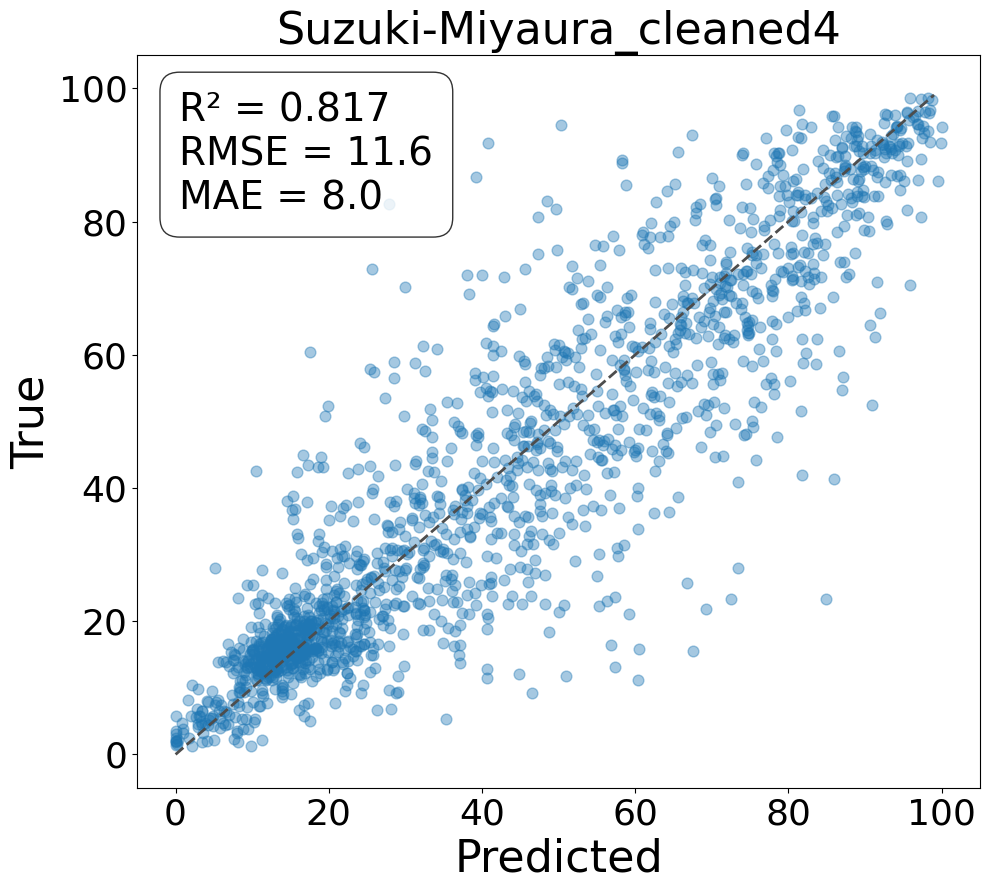

fine-tuned model Suzuki-Miyaura_cleaned5.pth
['CC(=O)OCC(=O)O[Pd].CC(C)(C)P(C1=CC=C[CH]1)C(C)(C)C.CC(C)(C)P(C1=CC=C[CH]1)C(C)(C)C.CCc1cccc(CC)c1.CO.Cc1ccc2c(cnn2C2CCCCO2)c1B1OC(C)(C)C(C)(C)O1.O.O=S(=O)(Oc1ccc2ncccc2c1)C(F)(F)F.[Fe].[K+].[OH-]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.5039253058316561]]
['CC(=O)OCC(=O)O[Pd].CC(C)(C)P(C1=CC=C[CH]1)C(C)(C)C.CC(C)(C)P(C1=CC=C[CH]1)C(C)(C)C.CCc1cccc(CC)c1.CO.Cc1ccc2c(cnn2C2CCCCO2)c1B1OC(C)(C)C(C)(C)O1.O.O=S(=O)(Oc1ccc2ncccc2c1)C(F)(F)F.[Fe].[K+].[OH-]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.30213167034204536]]
([0.4194079860771257], [[(-1.6384645700454712, -1.3537123203277588), (-0.8804301023483276, -1.0083355903625488), (-0.8281798958778381, -0.8791840076446533), (0.978643536567688, 1.2344379425048828), (-0.06295103579759598, -0.41229701042175293), (-0.9373551607131958, -0.5680239200592041), (0.7880004644393921, 1.7815598249435425), (-1.0021899938583374, -0.7821413278579712), (0.8707709312438965, 1.462580680847168), (-0

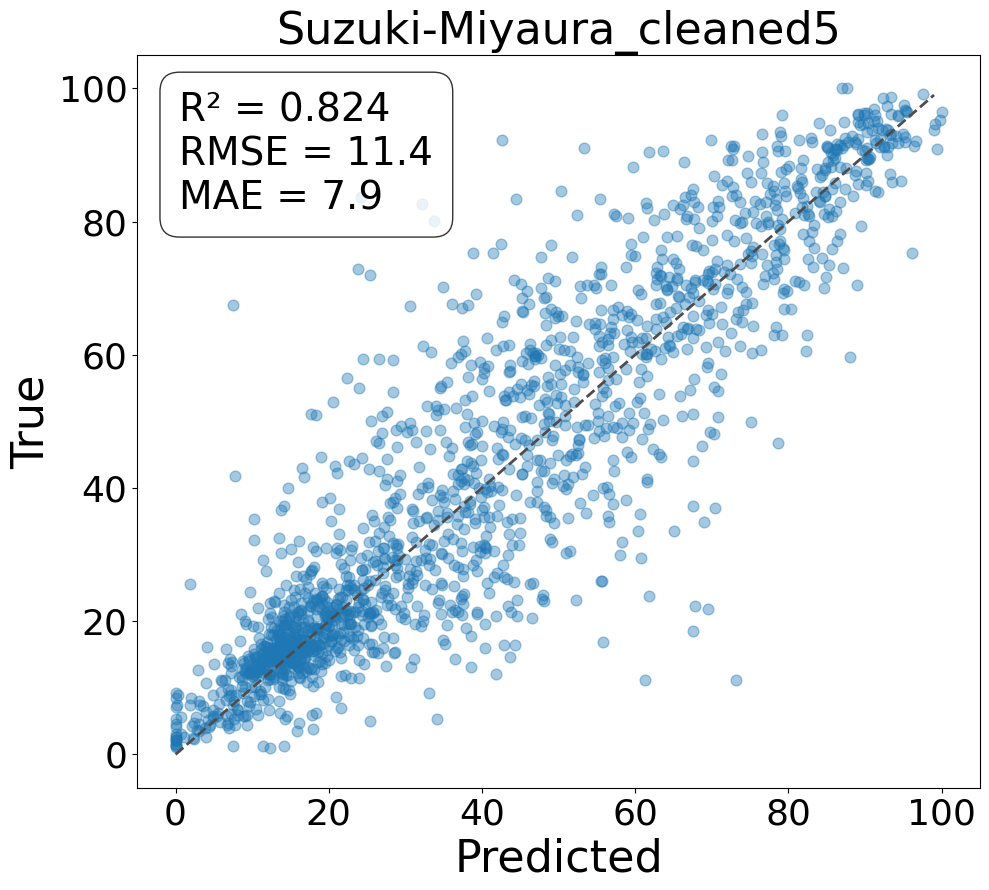

fine-tuned model Suzuki-Miyaura_cleaned6.pth
['Brc1ccc2ncccc2c1.C1CCOC1.CC(=O)OCC(=O)O[Pd].CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1.CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B1OC(C)(C)C(C)(C)O1.O.O=P([O-])([O-])[O-].[K+].[K+].[K+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.412965747708337]]
['Brc1ccc2ncccc2c1.C1CCOC1.CC(=O)OCC(=O)O[Pd].CC(C)c1cc(C(C)C)c(-c2ccccc2P(C2CCCCC2)C2CCCCC2)c(C(C)C)c1.CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B1OC(C)(C)C(C)(C)O1.O.O=P([O-])([O-])[O-].[K+].[K+].[K+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [-0.033290276636007386]]
([0.46039944827968515], [[(0.6253153085708618, -0.70823073387146), (-1.0515685081481934, -1.099937081336975), (-1.2398988008499146, -1.5145814418792725), (0.3447742462158203, 0.18202410638332367), (-1.2137336730957031, -1.3403366804122925), (1.7757169008255005, 0.9676945209503174), (-1.147666335105896, -0.7725914120674133), (0.5335777997970581, -0.019464829936623573), (-1.0485444068908691, -0.9639644622802734)

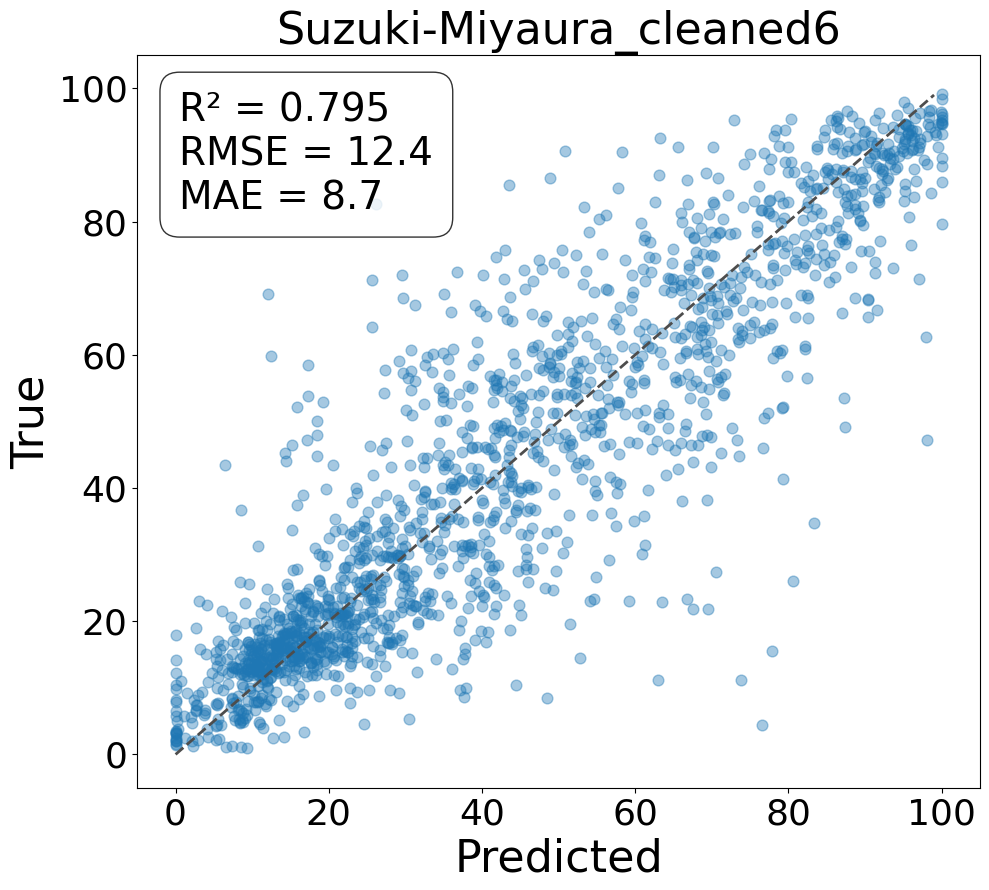

fine-tuned model Suzuki-Miyaura_cleaned7.pth
['Brc1ccc2ncccc2c1.C1CCC(P(C2CCCCC2)C2CCCCC2)CC1.CC(=O)OCC(=O)O[Pd].CCN(CC)CC.CCc1cccc(CC)c1.CN(C)C=O.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.O>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.382452775476815]]
['Brc1ccc2ncccc2c1.C1CCC(P(C2CCCCC2)C2CCCCC2)CC1.CC(=O)OCC(=O)O[Pd].CCN(CC)CC.CCc1cccc(CC)c1.CN(C)C=O.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.O>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [-0.15841189747456755]]
([0.42960259463723427], [[(-0.11946394294500351, 0.38192152976989746), (2.0007359981536865, 2.051816463470459), (0.8106398582458496, 0.5594700574874878), (-0.907099723815918, -0.6664396524429321), (-0.23155787587165833, -0.17964474856853485), (-0.32691100239753723, 0.2718205451965332), (-0.779800295829773, -0.6669937968254089), (-0.9981570243835449, -0.9630494117736816), (-0.889757513999939, -0.6512435078620911), (-1.0664297342300415, -1.0437982082366943), (1.4795901775360107, 1.4409291744232178), (-1.2744191884994507, -1.0000730752944946),

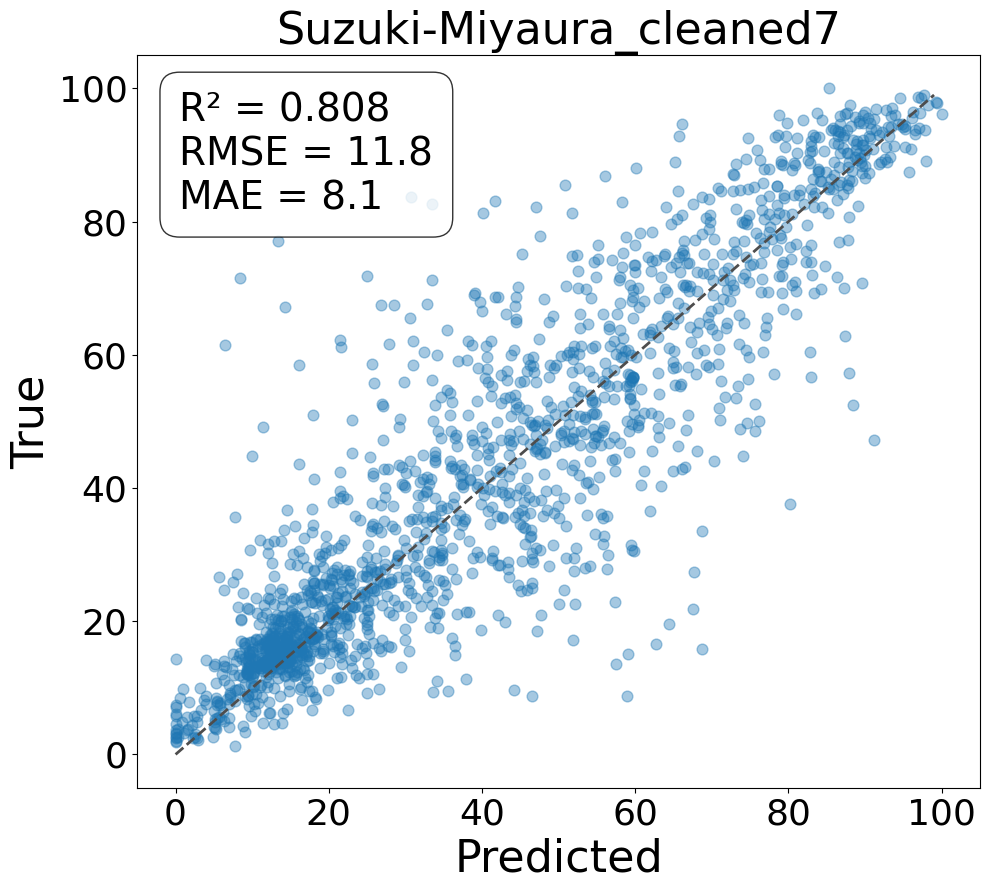

fine-tuned model Suzuki-Miyaura_cleaned8.pth
['C1CCOC1.CC(=O)OCC(=O)O[Pd].Cc1ccc2c(cnn2C2CCCCO2)c1Br.Cl.O.O.OB(O)c1ccc2ncccc2c1.[K+].[OH-]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.349989172313956]]
['C1CCOC1.CC(=O)OCC(=O)O[Pd].Cc1ccc2c(cnn2C2CCCCO2)c1Br.Cl.O.O.OB(O)c1ccc2ncccc2c1.[K+].[OH-]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [-0.25859264132435833]]
([0.458156093393956], [[(-0.513801097869873, 0.3575190007686615), (0.05109637230634689, 0.2330588698387146), (-0.865720808506012, -0.9391825795173645), (-0.7393333315849304, -0.8050816655158997), (-1.0653542280197144, -0.9585558176040649), (0.32241424918174744, -1.302052617073059), (1.7366164922714233, -0.16396509110927582), (-0.7855889201164246, -0.6759856939315796), (-0.8627850413322449, -0.9789376854896545), (-0.5595218539237976, -0.6319826245307922), (-0.9313284754753113, -0.9179304242134094), (-0.006871611811220646, 0.10478895157575607), (-0.4427444636821747, 1.1920268535614014), (-1.1218748092651367, -1.018301486

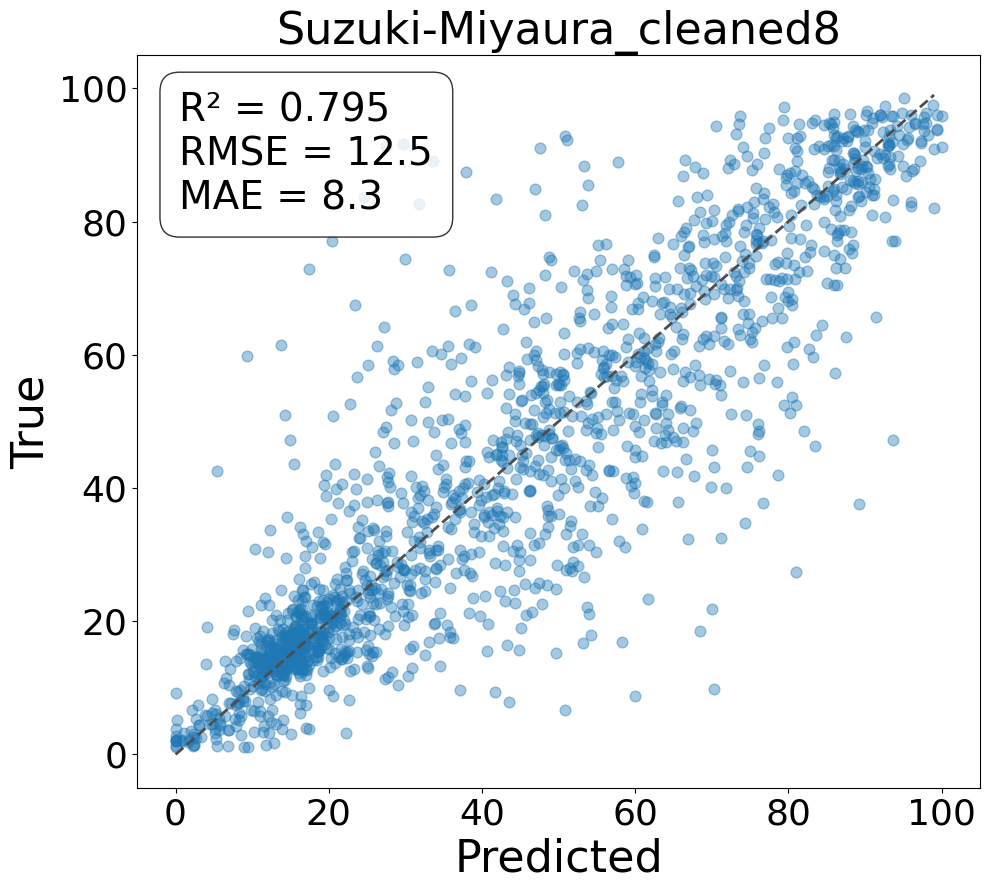

fine-tuned model Suzuki-Miyaura_cleaned9.pth
['C1CCOC1.CC(=O)OCC(=O)O[Pd].CC1(C)c2cccc(P(c3ccccc3)c3ccccc3)c2Oc2c(P(c3ccccc3)c3ccccc3)cccc21.CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.O.O=C([O-])O.O=S(=O)(Oc1ccc2ncccc2c1)C(F)(F)F.[Na+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [0.0825821294321349]]
['C1CCOC1.CC(=O)OCC(=O)O[Pd].CC1(C)c2cccc(P(c3ccccc3)c3ccccc3)c2Oc2c(P(c3ccccc3)c3ccccc3)cccc21.CCc1cccc(CC)c1.Cc1ccc2c(cnn2C2CCCCO2)c1B(O)O.O.O=C([O-])O.O=S(=O)(Oc1ccc2ncccc2c1)C(F)(F)F.[Na+]>>Cc1ccc2c(cnn2C2CCCCO2)c1-c1ccc2ncccc2c1<end>', [-1.2557848494892128]]
([0.4588689013445297], [[(-0.9380108714103699, -0.9607951045036316), (1.1139626502990723, 0.21647238731384277), (0.05202241986989975, -0.31596753001213074), (-0.003633059561252594, -0.0844118520617485), (-0.9902536273002625, -1.0281696319580078), (-1.0538911819458008, -0.9771329760551453), (0.7667962908744812, -0.13349363207817078), (-1.5588890314102173, -1.035786509513855), (-0.7488319873809814, -0.0007932329899631441), (0.

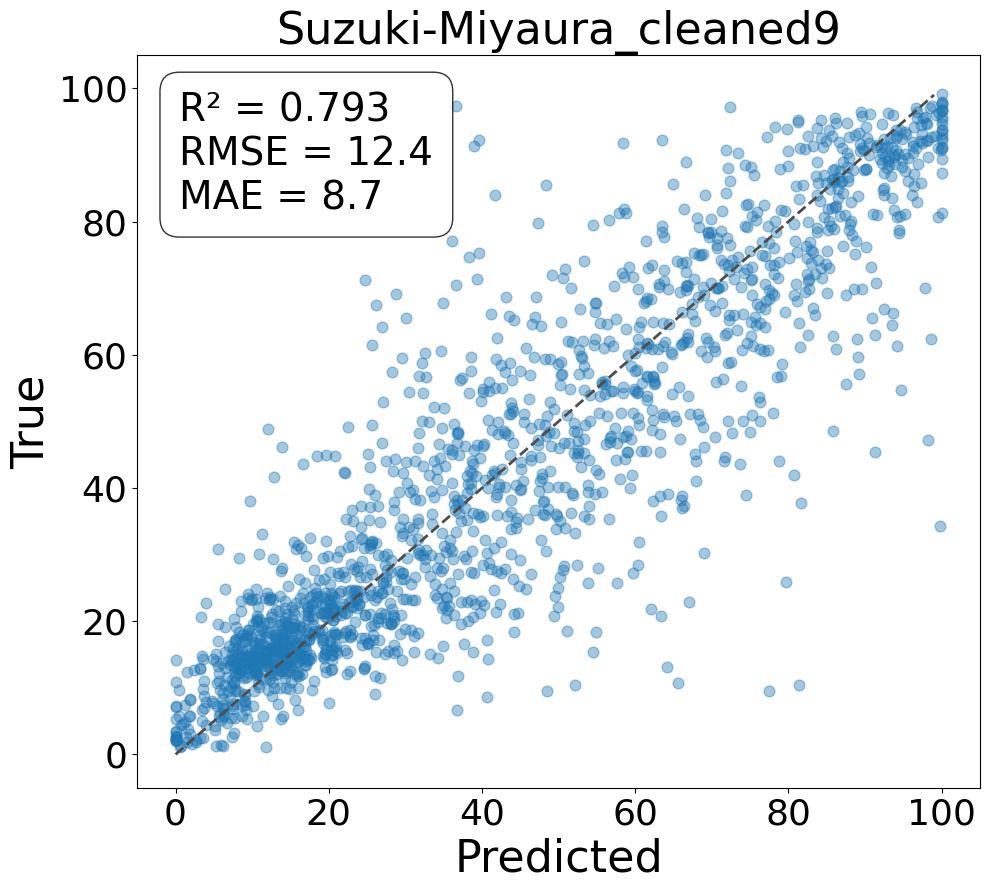

In [3]:
#训练：验证：测试 6：1：3
from ChemBart import CB_Regression
import json
import matplotlib.patches as mpatches
import matplotlib.pyplot as plt
from sklearn.metrics import mean_squared_error, r2_score, mean_absolute_error
import numpy as np

TRAIN = False
LABEL_NUM = 1

task_token = ["<n00>", "<n01>", "<n02>","<n03>", "<n04>"]
ends = "".join(task_token[:LABEL_NUM - 1]) + "<end>"

for i in range(0, 10):
    json_file_path = f'data/yield/SM_cleaned/sm{i}.json'
    model_name = f"Suzuki-Miyaura_cleaned{i}"
    c = CB_Regression(name = model_name, pre_model='ChemBart_MIT_6',label_num = LABEL_NUM, device = "cuda:2") #"cuda:0", "cuda:1" etc.
    with open(json_file_path) as f:
        l = json.load(f)
    for i in range(len(l)):
        l[i][0] += ends
    print(l[1])

    #划分数据集
    train_prop = 0.6
    valid_prop = 0.1

    train_size = int(train_prop*len(l))
    valid_size = int(valid_prop*len(l))
    test_size = len(l) - train_size - valid_size

    #数据标准化
    # 提取标签值
    labels = [item[1] for item in l]
    # 计算训练集的均值和标准差
    train_labels = labels[:train_size]
    mean = np.mean(train_labels)
    std = np.std(train_labels)
    # 标准化标签值
    standardized_labels = [(label - mean) / std for label in labels]
    # 将标准化后的标签值放回原始数据中
    for i, item in enumerate(l):
        l[i][1] = [float(standardized_labels[i])]
    print(l[1])

    if TRAIN:
        c.fit(data = l[0:train_size+valid_size], epoch = 1000, batch_size = 4, tr=train_size, val=valid_size, te = test_size, id_maxlen =300 )
        #data, epoch, batch size, train num, val num, test num, max input length
    else:
        out = c.test(l[-test_size:-1], batch_size = 4)
        print(out)
    
    (RMSE_list, reslist) = c.test(l[-test_size:-1], batch_size = 4)

    # 提取预测值和标签
    y_pred, y_test = [], []
    for sublist in reslist:
        # 确保每个子列表中的元素都是二元组 (prediction, label)
        if all(isinstance(item, tuple) and len(item) == 2 for item in sublist):
            y_pred.extend([(item[0] * std + mean)*100 for item in sublist])
            y_pred = np.clip(y_pred, 0, 100)
            y_test.extend([(item[1] * std + mean)*100 for item in sublist])
        else:
            raise ValueError("Each element in sublist must be a tuple of length 2.")
    plot = make_plot(y_test, y_pred, model_name)